In [96]:
import numpy as np


def rescale_x(x_old, x1_old=-0.91, x1_new=0, x2_old=1.105, x2_new=0.5):
    """
    重新縮放 x 軸，使得:
    - x1_old 映射到 x1_new
    - x2_old 映射到 x2_new

    :param x_old: 要轉換的舊 x 軸數據（NumPy array 或 數值）
    :param x1_old, x1_new: 第一個已知對應點
    :param x2_old, x2_new: 第二個已知對應點
    :return: 轉換後的新 x 軸數據
    """
    a = (x2_new - x1_new) / (x2_old - x1_old)  # 計算縮放係數
    b = x1_new - a * x1_old                    # 計算偏移量
    return a * x_old + b



In [75]:
import Labber
import matplotlib.pyplot as plt
np.bool=bool
np.float=float
d1 = r'C:\Users\SQC\Desktop\ZCU\ZCU_Data\Test049[02]\2023\12\Data_1202\Test049_TwoTone_flux_008.hdf5'
d1 = Labber.LogFile(d1)
x, y = d1.getTraceXY()
data = d1.getData()
step=len(data)
step

d1flux = d1.getStepChannels()[1]['values']

In [76]:
z1 = []
for i in range(step):
    x, y = d1.getTraceXY(entry=i)
    z1.append(x[np.argmin(np.abs(y))])

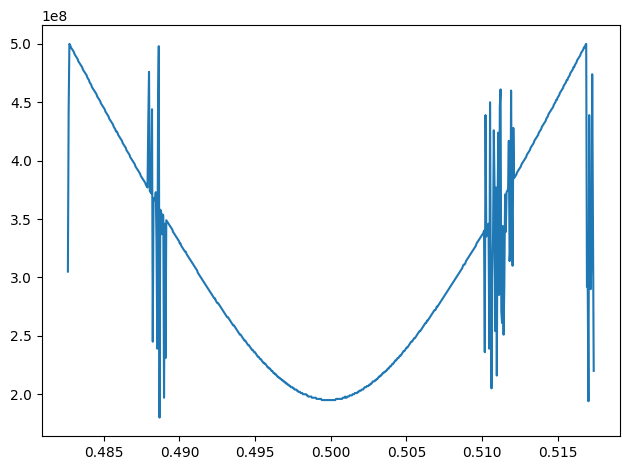

In [97]:
plt.plot(rescale_x(d1flux*1e3),z1)
plt.tight_layout()

In [66]:
data2=r'C:\Users\SQC\Desktop\ZCU\ZCU_Data\Test049[02]\2023\11\Data_1126\Test049_TwoTone_flux_004.hdf5'
d2 = Labber.LogFile(data2)
x, y = d2.getTraceXY()
data2 = d2.getData()
step2=len(data2)


d2flux = d2.getStepChannels()[1]['values']

In [67]:
z2 = []

for i in range(step2):
    x, y = d2.getTraceXY(entry=i)
    z2.append(x[np.argmin(np.angle(y))])



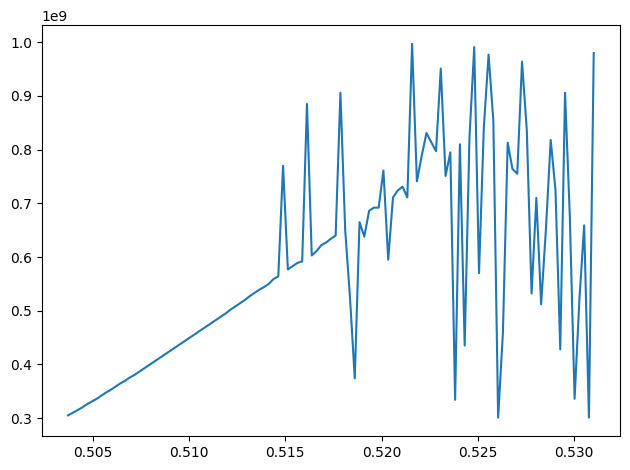

In [98]:

# plt.plot(rescale_x(d2flux*1e3)[:n],z2[:n])
plt.plot(rescale_x(d2flux*1e3),z2)
plt.tight_layout()

In [109]:
data3=r'C:\Users\SQC\Desktop\ZCU\ZCU_Data\Test049[02]\2023\11\Data_1125\Test049_TwoTone_flux_001.hdf5'
d3 = Labber.LogFile(data3)
x, y = d3.getTraceXY()
data3 = d3.getData()
step3=len(data3)


d3flux = d3.getStepChannels()[1]['values']

In [110]:
z3=[]
nstep = np.arange(140, 201, 1)
for i in (nstep):
    x, y = d3.getTraceXY(entry=i)
    z3.append(x[np.argmin(np.abs(y))])

In [122]:
z4=[]
nstep = np.arange(0, 60, 1)
for i in (nstep):
    x, y = d3.getTraceXY(entry=i)
    z4.append(x[np.argmin(np.abs(y))])

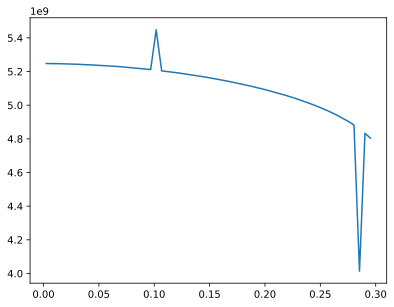

In [123]:
# plt.plot(rescale_x(d3flux[140:]*1e3), z3)

plt.plot(rescale_x(d3flux[:60]*1e3), z4)

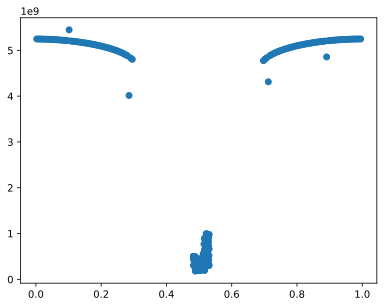

In [124]:
# z = z1 + z3[:15]
z = z4 + z1 + z2 + z3
# nflux=np.concatenate((d1flux,d2flux[:15][::-1]))
nflux=np.concatenate((d3flux[:60], d1flux,d2flux, d3flux[140:]))
#nflux = rescale_x(d1flux*1e3) + rescale_x(d2flux[:15]*1e3)[::-1]
plt.scatter(rescale_x(nflux*1e3), z)

In [127]:
np.savez('data.npz', x = rescale_x(nflux*1e3), y = np.array(z))

In [128]:
import scqubits as scq
import scipy
import numpy as np 
datanp = np.load('data.npz')
x=datanp['x']
y=datanp['y']

In [129]:
import scqubits as scq
import scipy
def bare_fluxonium(flux, EJ, EC, EL):
    fluxonium = scq.Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        flux=flux,
        cutoff=100,
    )
    evals = fluxonium.get_spectrum_vs_paramvals('flux', flux).energy_table
    return evals[:, 1] - evals[:, 0]

In [133]:
popt_qub, _ = scipy.optimize.curve_fit(
    bare_fluxonium,
    x,
    y,
    p0=(4, 1, 1),
    bounds=((3, 0.5, 0.5), (5, 1.2, 1.2)),
)
print("Success")

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

Success


In [134]:
popt_qub

array([4.99999999, 1.2       , 1.2       ])

Spectral data:   0%|          | 0/933 [00:00<?, ?it/s]

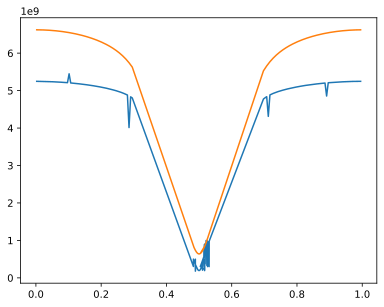

In [135]:
plt.plot(x, z)
plt.plot(x, bare_fluxonium(x, *popt_qub)*1e9)

In [132]:
popt_qub

array([5.61319271, 5.3240961 , 2.84353107])